### ARIMA Modelling: Mathematical Foundations and Applications
#### Time Series Analysis using ARIMA
---

### 1. Introduction to Time Series and ARIMA

A **time series** is a sequence of observations $\{y_t\}$ recorded at equally spaced time intervals. Examples include stock prices, monthly sales, temperature readings, and GDP figures.

Time series data exhibits four key patterns:
- **Trend**: Long-run increase or decrease
- **Seasonality**: Regular repeating patterns
- **Cyclic**: Irregular fluctuations over longer periods
- **Irregular/Noise**: Random variation

**ARIMA** (AutoRegressive Integrated Moving Average) is one of the most widely used statistical models for time series forecasting. It unifies three modelling ideas:

| Component | Symbol | Role |
|-----------|--------|------|
| AutoRegression | AR(p) | Past values predict current value |
| Integration | I(d) | Differencing to achieve stationarity |
| Moving Average | MA(q) | Past forecast errors correct current prediction |

The model is written as **ARIMA(p, d, q)**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Key Components: AR, I, MA

#### 2.1 AutoRegressive Model - AR(p)

An AR(p) model expresses the current value as a **linear combination of its p past values** plus white noise:

**Intuition**: Like regressing a variable on its own history - tomorrow's temperature depends on today's and yesterday's.

#### 2.2 Moving Average Model - MA(q)

An MA(q) model expresses the current value as a **linear combination of past forecast errors**:

#### 2.3 Integration - I(d)

The 'I' in ARIMA handles **non-stationarity** by differencing the series d times:

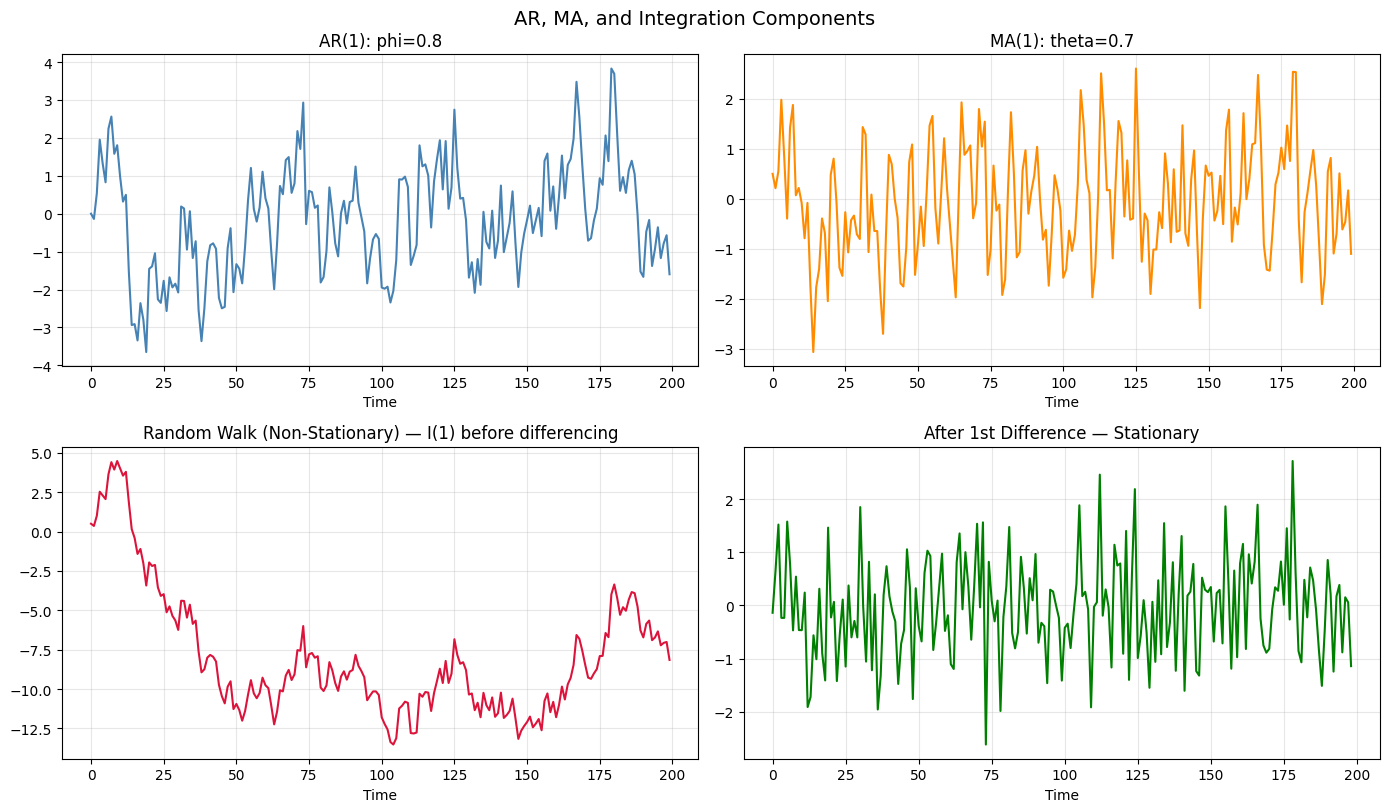

In [3]:
# Simulate AR(1), MA(1) processes to visualize each component
np.random.seed(42)
n = 200
eps = np.random.normal(0, 1, n)

# AR(1): y_t = 0.8*y_{t-1} + eps_t
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = 0.8 * ar1[t-1] + eps[t]

# MA(1): y_t = eps_t + 0.7*eps_{t-1}
ma1 = eps + 0.7 * np.roll(eps, 1)
ma1[0] = eps[0]

# I(1): cumulative sum of white noise (random walk, non-stationary)
rw = np.cumsum(eps)
rw_diff = np.diff(rw)  # first difference -> back to stationary

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(ar1, color='steelblue'); axes[0,0].set_title('AR(1): phi=0.8')
axes[0,1].plot(ma1, color='darkorange'); axes[0,1].set_title('MA(1): theta=0.7')
axes[1,0].plot(rw, color='crimson'); axes[1,0].set_title('Random Walk (Non-Stationary) — I(1) before differencing')
axes[1,1].plot(rw_diff, color='green'); axes[1,1].set_title('After 1st Difference — Stationary')
for ax in axes.flatten():
    ax.set_xlabel('Time')
plt.tight_layout()
plt.suptitle('AR, MA, and Integration Components', fontsize=14, y=1.01)
plt.show()

### 3. Mathematical Formulation of ARIMA(p, d, q)

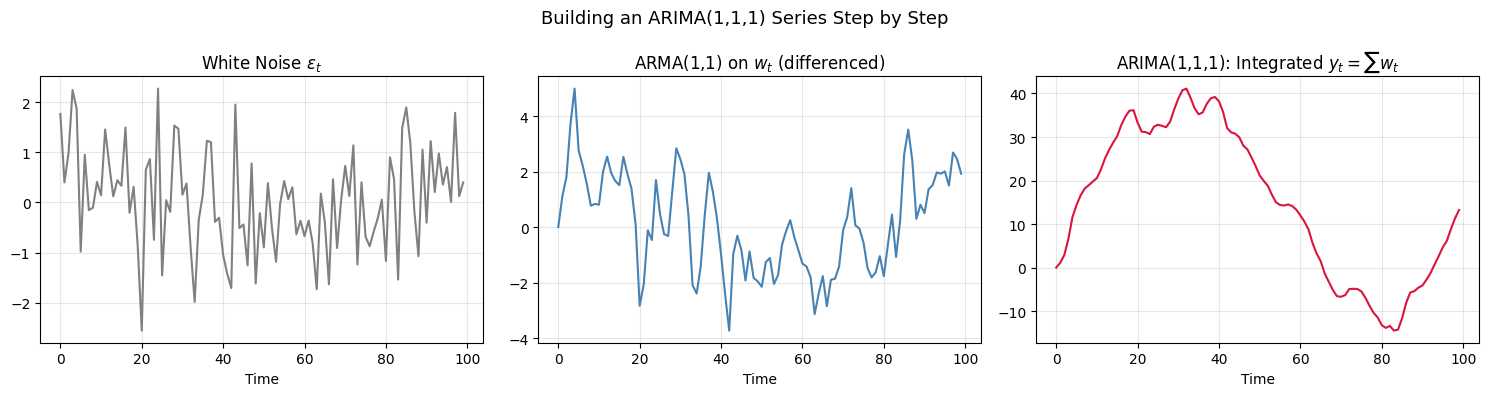

ARIMA(1,1,1) model: phi_1=0.6, theta_1=0.4, d=1
Series mean: 14.66, Std: 17.10


In [4]:
# Demonstrate the backshift operator effect mathematically with a simple simulation
np.random.seed(0)
n = 100
eps = np.random.normal(0, 1, n)

# ARIMA(1,1,1): simulate by building on differenced series
# Step 1: ARMA(1,1) on w_t
w = np.zeros(n)
for t in range(1, n):
    w[t] = 0.6 * w[t-1] + eps[t] + 0.4 * eps[t-1]

# Step 2: Integrate once (cumsum) to get y_t
y = np.cumsum(w)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(eps, color='gray'); axes[0].set_title('White Noise $\\varepsilon_t$')
axes[1].plot(w, color='steelblue'); axes[1].set_title('ARMA(1,1) on $w_t$ (differenced)')
axes[2].plot(y, color='crimson'); axes[2].set_title('ARIMA(1,1,1): Integrated $y_t = \\sum w_t$')
for ax in axes:
    ax.set_xlabel('Time')
plt.suptitle('Building an ARIMA(1,1,1) Series Step by Step', fontsize=13)
plt.tight_layout()
plt.show()

print("ARIMA(1,1,1) model: phi_1=0.6, theta_1=0.4, d=1")
print(f"Series mean: {y.mean():.2f}, Std: {y.std():.2f}")

### 4. Stationarity and Differencing

#### What is Stationarity?

ARIMA requires stationarity. Non-stationary series (trending, heteroscedastic) must be transformed first.

#### Augmented Dickey-Fuller (ADF) Test

The ADF test checks the null hypothesis $H_0$: the series has a unit root (non-stationary).

**Decision rule**: If p-value < 0.05, reject $H_0$ — the series is stationary.

Dataset shape: (144,)
Period: 1949-01-01 to 1960-12-01


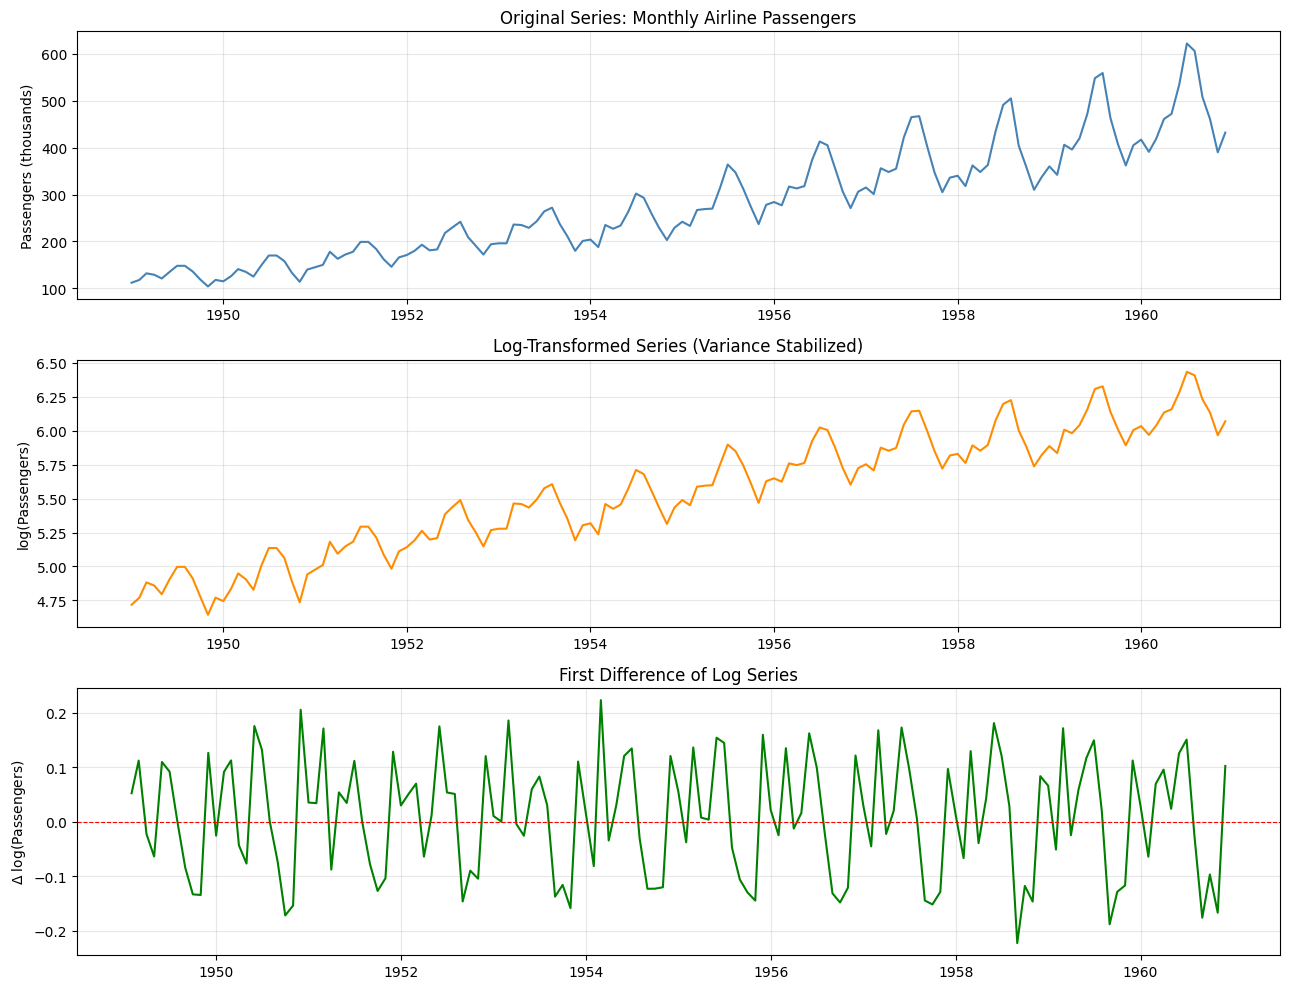


--- ADF Test: Original ---
  Test Statistic : 0.8154
  p-value        : 0.9919
  Stationary?    : NO

--- ADF Test: Log-transformed ---
  Test Statistic : -1.7170
  p-value        : 0.4224
  Stationary?    : NO

--- ADF Test: First Difference of Log ---
  Test Statistic : -2.7171
  p-value        : 0.0711
  Stationary?    : NO


In [5]:
# Use airline passengers dataset (classic time series benchmark)
# Monthly totals of international airline passengers, 1949-1960
from statsmodels.datasets import get_rdataset

try:
    data = get_rdataset('AirPassengers').data
    # Parse the time column
    data.index = pd.date_range(start='1949-01', periods=len(data), freq='MS')
    passengers = data['value']
except:
    # Fallback: generate synthetic data with trend + seasonality
    np.random.seed(42)
    t = np.arange(144)
    passengers = pd.Series(
        100 + 2*t + 30*np.sin(2*np.pi*t/12) + np.random.normal(0, 10, 144),
        index=pd.date_range('1949-01', periods=144, freq='MS')
    )
    passengers = passengers.apply(lambda x: max(x, 50)).astype(int)

print(f"Dataset shape: {passengers.shape}")
print(f"Period: {passengers.index[0].date()} to {passengers.index[-1].date()}")

# Plot raw series
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(passengers, color='steelblue', linewidth=1.5)
axes[0].set_title('Original Series: Monthly Airline Passengers')
axes[0].set_ylabel('Passengers (thousands)')

# Log transform to stabilize variance
log_pass = np.log(passengers)
axes[1].plot(log_pass, color='darkorange', linewidth=1.5)
axes[1].set_title('Log-Transformed Series (Variance Stabilized)')
axes[1].set_ylabel('log(Passengers)')

# First difference of log (removes trend)
diff_log = log_pass.diff().dropna()
axes[2].plot(diff_log, color='green', linewidth=1.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_title('First Difference of Log Series')
axes[2].set_ylabel('$\\Delta$ log(Passengers)')

plt.tight_layout()
plt.show()

# ADF test on original and differenced series
def adf_summary(series, label):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {label} ---")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Stationary?    : {'YES' if result[1] < 0.05 else 'NO'}")

adf_summary(passengers, 'Original')
adf_summary(log_pass, 'Log-transformed')
adf_summary(diff_log, 'First Difference of Log')

### 5. Identifying Model Parameters (ACF, PACF, AIC/BIC)

#### Autocorrelation Function (ACF)

The ACF at lag $k$ measures the correlation between $y_t$ and $y_{t-k}$:

#### Partial Autocorrelation Function (PACF)

PACF at lag $k$ measures the correlation between $y_t$ and $y_{t-k}$ **after removing** the effect of intermediate lags. Computed via the Yule-Walker equations:

#### Identification Table

| Model | ACF | PACF |
|-------|-----|------|
| AR(p) | Decays gradually | Cuts off after lag p |
| MA(q) | Cuts off after lag q | Decays gradually |
| ARMA(p,q) | Decays gradually | Decays gradually |

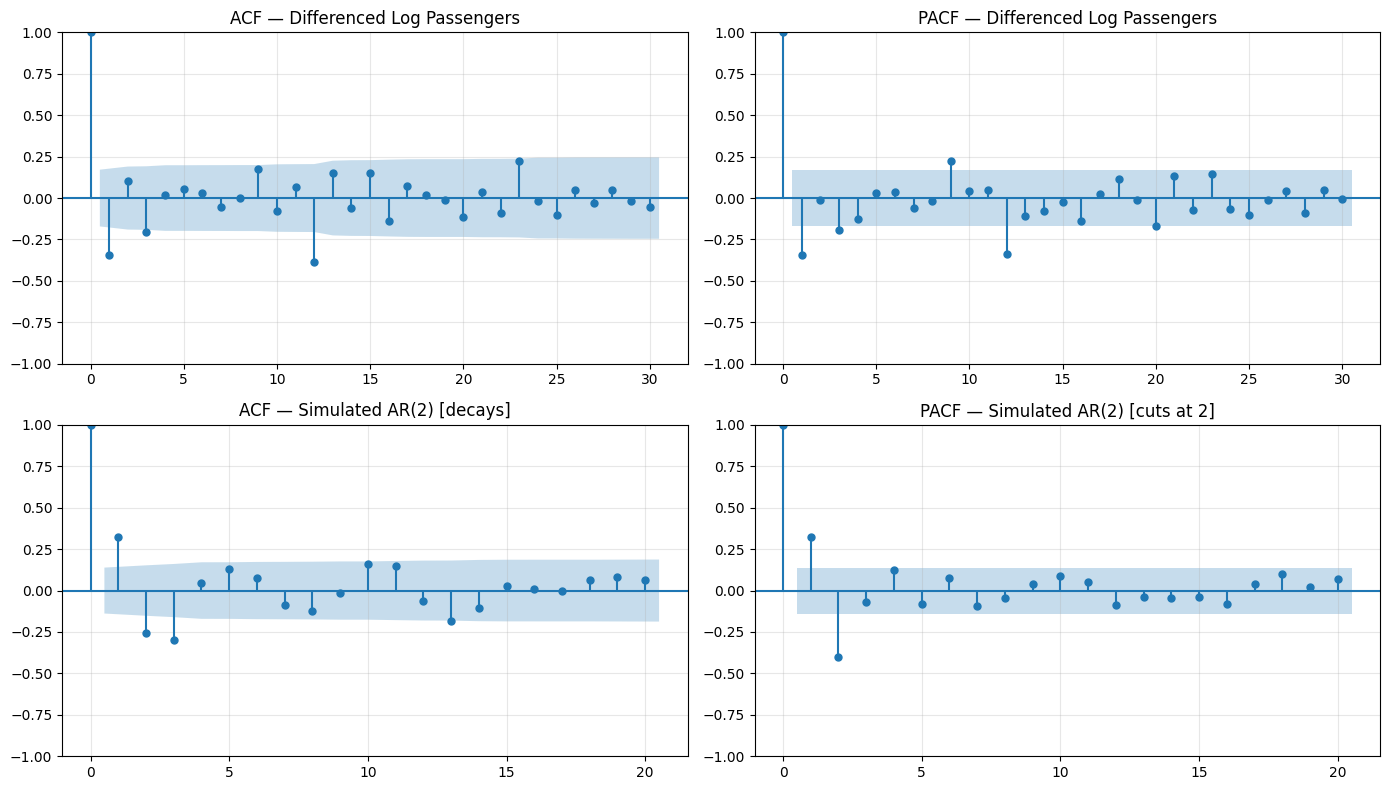

Interpretation:
  AR(2) PACF spikes at lags 1 and 2, then cuts off — confirms AR order = 2
  AR(2) ACF decays geometrically — typical AR behaviour


In [6]:
# Apply seasonal differencing (lag 12) to also remove seasonality
log_passengers = np.log(passengers)
diff1 = log_passengers.diff(12).dropna()   # seasonal difference
diff2 = diff1.diff(1).dropna()             # then first difference

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(diff2, lags=30, ax=axes[0,0], title='ACF — Differenced Log Passengers')
plot_pacf(diff2, lags=30, ax=axes[0,1], title='PACF — Differenced Log Passengers', method='ywm')

# Simulated pure AR(2) for comparison
np.random.seed(1)
ar2_sim = np.zeros(200)
e = np.random.normal(0, 1, 200)
for t in range(2, 200):
    ar2_sim[t] = 0.5*ar2_sim[t-1] - 0.3*ar2_sim[t-2] + e[t]

plot_acf(ar2_sim, lags=20, ax=axes[1,0], title='ACF — Simulated AR(2) [decays]')
plot_pacf(ar2_sim, lags=20, ax=axes[1,1], title='PACF — Simulated AR(2) [cuts at 2]', method='ywm')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  AR(2) PACF spikes at lags 1 and 2, then cuts off — confirms AR order = 2")
print("  AR(2) ACF decays geometrically — typical AR behaviour")

In [7]:
# Grid search AIC/BIC over (p, d, q) combinations
# Use log-transformed airline data with d=1

log_pass = np.log(passengers)

results_aic = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(log_pass, order=(p, 1, q)).fit()
            results_aic.append({'p': p, 'd': 1, 'q': q, 'AIC': model.aic, 'BIC': model.bic})
        except:
            pass

aic_df = pd.DataFrame(results_aic).sort_values('AIC').reset_index(drop=True)
print("Top 8 models by AIC:")
print(aic_df.head(8).to_string(index=False))
print(f"\nBest model by AIC: ARIMA({int(aic_df.iloc[0]['p'])}, 1, {int(aic_df.iloc[0]['q'])})")
print(f"Best model by BIC: ARIMA({int(aic_df.sort_values('BIC').iloc[0]['p'])}, 1, {int(aic_df.sort_values('BIC').iloc[0]['q'])})")

Top 8 models by AIC:
 p  d  q         AIC         BIC
 3  1  3 -277.217554 -256.477642
 3  1  2 -251.799916 -234.022848
 2  1  1 -251.463509 -239.612130
 3  1  1 -250.449948 -235.635725
 1  1  2 -248.864828 -237.013449
 2  1  3 -248.131739 -230.354672
 2  1  2 -247.779684 -232.965461
 1  1  3 -246.866208 -232.051985

Best model by AIC: ARIMA(3, 1, 3)
Best model by BIC: ARIMA(3, 1, 3)


C:\Users\14jay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 6. Building and Fitting the ARIMA Model

#### Parameter Estimation

ARIMA parameters $\{\phi_i, \theta_j, \sigma^2\}$ are estimated by **Maximum Likelihood Estimation (MLE)**.

In practice, statsmodels uses the **Kalman filter** to evaluate the likelihood efficiently, especially for missing data or exact initial conditions.

#### Training / Test Split

For time series, we always split chronologically - no random shuffling. The last portion is held out for out-of-sample evaluation.

In [8]:
# Fit ARIMA(1,1,1) on log-transformed passengers
# Train: first 120 months, Test: last 24 months

log_pass = np.log(passengers)
train = log_pass.iloc[:120]
test  = log_pass.iloc[120:]

# Fit model
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()

print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 103.840
Date:                Tue, 28 Apr 2026   AIC                           -201.680
Time:                        22:51:02   BIC                           -193.342
Sample:                    01-01-1949   HQIC                          -198.294
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5762      0.191     -3.015      0.003      -0.951      -0.202
ma.L1          0.8348      0.117      7.133      0.000       0.605       1.064
sigma2         0.0102      0.002      5.556      0.0

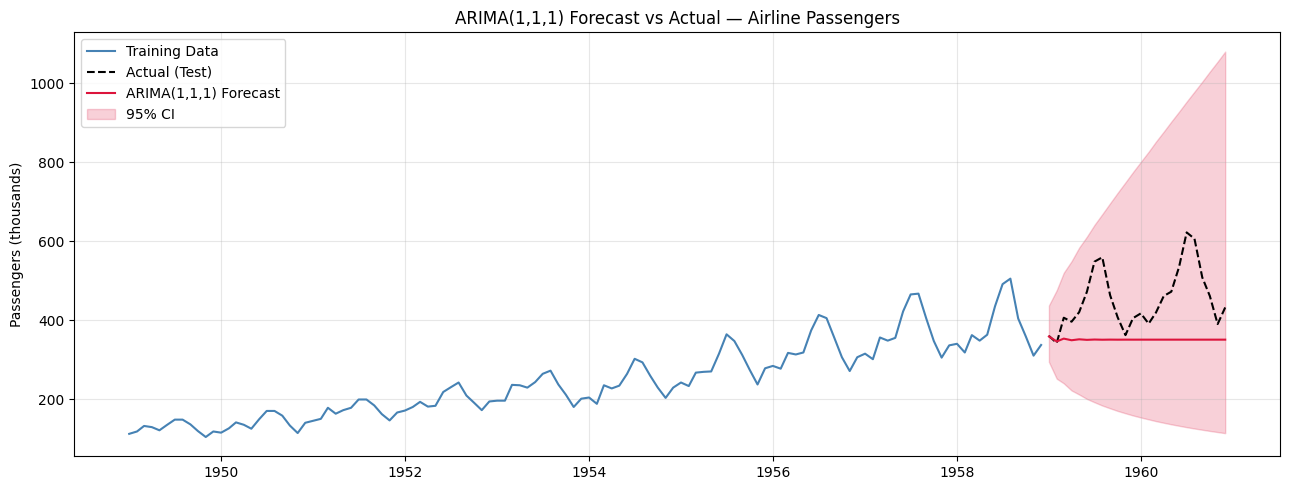

Forecast Accuracy (out-of-sample):
  RMSE : 126.16
  MAE  : 101.87
  MAPE : 20.56%


In [9]:
# Forecast 24 steps ahead
forecast_result = fitted.get_forecast(steps=len(test))
forecast_mean   = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

# Back-transform from log scale
fc_exp   = np.exp(forecast_mean)
ci_lower = np.exp(conf_int.iloc[:, 0])
ci_upper = np.exp(conf_int.iloc[:, 1])
actual   = np.exp(test)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(np.exp(train), label='Training Data', color='steelblue')
ax.plot(actual, label='Actual (Test)', color='black', linestyle='--')
ax.plot(fc_exp, label='ARIMA(1,1,1) Forecast', color='crimson')
ax.fill_between(fc_exp.index, ci_lower, ci_upper, alpha=0.2, color='crimson', label='95% CI')
ax.set_title('ARIMA(1,1,1) Forecast vs Actual — Airline Passengers')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

# Accuracy metrics
rmse = np.sqrt(mean_squared_error(actual, fc_exp))
mae  = mean_absolute_error(actual, fc_exp)
mape = np.mean(np.abs((actual - fc_exp) / actual)) * 100

print(f"Forecast Accuracy (out-of-sample):")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")

### 7. Model Diagnostics and Validation

A well-specified ARIMA should produce residuals that are:
1. **White noise** — no autocorrelation (checked via ACF and Ljung-Box test)
2. **Normally distributed** — checked via Q-Q plot and Jarque-Bera test
3. **Zero mean** — no systematic bias

#### Ljung-Box Test

Tests whether any group of autocorrelations is significantly different from zero

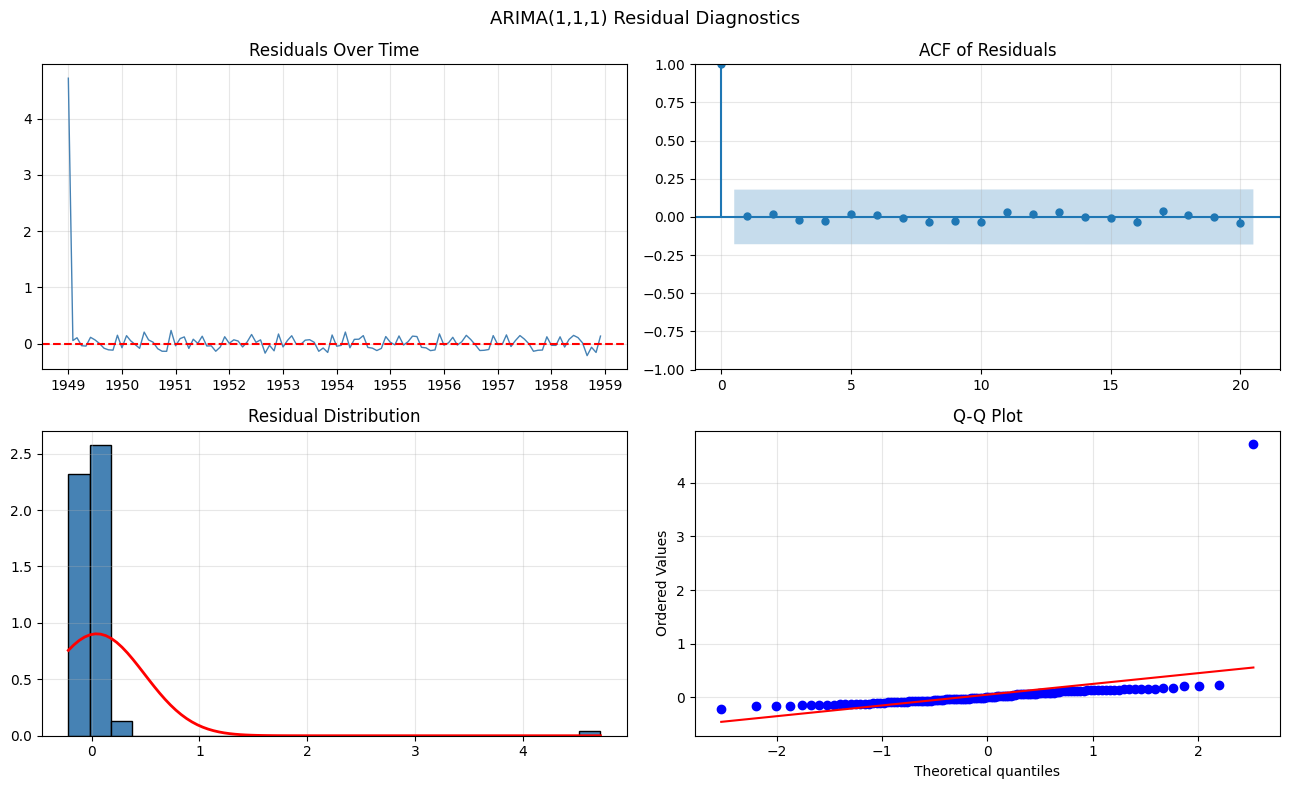

Ljung-Box Test on Residuals:
     lb_stat  lb_pvalue
10  0.623101   0.999981
20  1.568642   1.000000

Interpretation: p-value > 0.05 means residuals resemble white noise (good model).

Jarque-Bera Normality Test: stat=55095.8902, p-value=0.0000
Residuals normally distributed: NO


In [10]:
from scipy import stats

residuals = fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Residuals over time
axes[0,0].plot(residuals, color='steelblue', linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals Over Time')

# ACF of residuals
plot_acf(residuals.dropna(), lags=20, ax=axes[0,1], title='ACF of Residuals')

# Histogram
axes[1,0].hist(residuals.dropna(), bins=25, edgecolor='black', color='steelblue', density=True)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,0].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2)
axes[1,0].set_title('Residual Distribution')

# Q-Q plot
stats.probplot(residuals.dropna(), dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot')

plt.suptitle('ARIMA(1,1,1) Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Ljung-Box Test on Residuals:")
print(lb_test)
print("\nInterpretation: p-value > 0.05 means residuals resemble white noise (good model).")

# Normality test
stat, p_jb = stats.jarque_bera(residuals.dropna())
print(f"\nJarque-Bera Normality Test: stat={stat:.4f}, p-value={p_jb:.4f}")
print(f"Residuals normally distributed: {'YES' if p_jb > 0.05 else 'NO'}")

### 8. Extensions: SARIMA and ARIMAX

#### 8.1 SARIMA — Seasonal ARIMA

Standard ARIMA cannot model periodic seasonality directly. **SARIMA** (Seasonal ARIMA) extends ARIMA with seasonal AR and MA terms at lag $s$ (the seasonal period, e.g. $s=12$ for monthly data).

Notation: **SARIMA(p, d, q)(P, D, Q)$_s$**

#### 8.2 ARIMAX — ARIMA with Exogenous Variables

**ARIMAX** incorporates external (exogenous) predictors $\mathbf{x}_t$:

**Use cases**: Forecasting sales with advertising spend as exogenous input, demand forecasting with price and promotions, electricity load with temperature as covariate.

In [11]:
# Fit SARIMA(1,1,1)(1,1,1,12) — captures monthly seasonality in airline data
log_pass = np.log(passengers)
train_s = log_pass.iloc[:120]
test_s  = log_pass.iloc[120:]

sarima_model = SARIMAX(train_s,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 171.311
Date:                            Tue, 28 Apr 2026   AIC                           -332.622
Time:                                    22:53:01   BIC                           -319.959
Sample:                                01-01-1949   HQIC                          -327.509
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0505      0.255      0.198      0.843      -0.449       0.550
ma.L1         -0.4640      0.235   

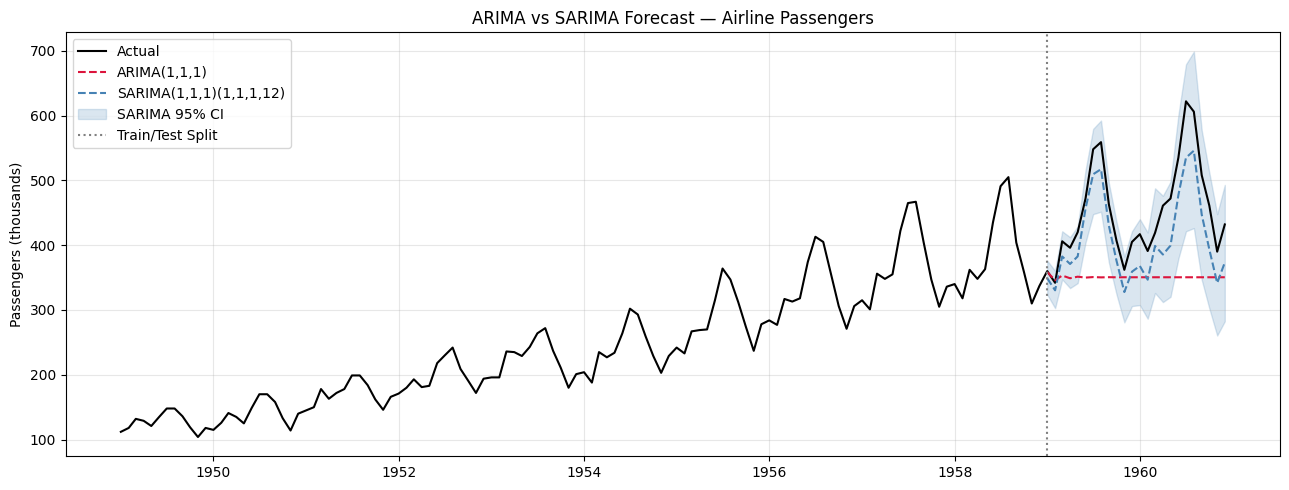

Model Comparison (Test Set):
Model                                RMSE       MAPE
--------------------------------------------------
ARIMA(1,1,1)                       126.16     20.56%
SARIMA(1,1,1)(1,1,1,12)             48.26      9.48%

SARIMA captures seasonality — significantly lower error.


In [12]:
# Compare ARIMA vs SARIMA forecasts
sarima_fc = sarima_fit.get_forecast(steps=len(test_s))
sarima_mean = np.exp(sarima_fc.predicted_mean)
sarima_ci   = sarima_fc.conf_int().apply(np.exp)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(passengers, label='Actual', color='black', linewidth=1.5)
ax.plot(fc_exp, label='ARIMA(1,1,1)', color='crimson', linestyle='--')
ax.plot(sarima_mean, label='SARIMA(1,1,1)(1,1,1,12)', color='steelblue', linestyle='--')
ax.fill_between(sarima_mean.index,
                sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                alpha=0.2, color='steelblue', label='SARIMA 95% CI')
ax.axvline(passengers.index[120], color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.set_title('ARIMA vs SARIMA Forecast — Airline Passengers')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

# Compare accuracy
actual_test = np.exp(test_s)
rmse_arima  = np.sqrt(mean_squared_error(actual_test, fc_exp))
rmse_sarima = np.sqrt(mean_squared_error(actual_test, sarima_mean))
mape_arima  = np.mean(np.abs((actual_test - fc_exp) / actual_test)) * 100
mape_sarima = np.mean(np.abs((actual_test - sarima_mean) / actual_test)) * 100

print(f"Model Comparison (Test Set):")
print(f"{'Model':<30} {'RMSE':>10} {'MAPE':>10}")
print(f"{'-'*50}")
print(f"{'ARIMA(1,1,1)':<30} {rmse_arima:>10.2f} {mape_arima:>9.2f}%")
print(f"{'SARIMA(1,1,1)(1,1,1,12)':<30} {rmse_sarima:>10.2f} {mape_sarima:>9.2f}%")
print("\nSARIMA captures seasonality — significantly lower error.")

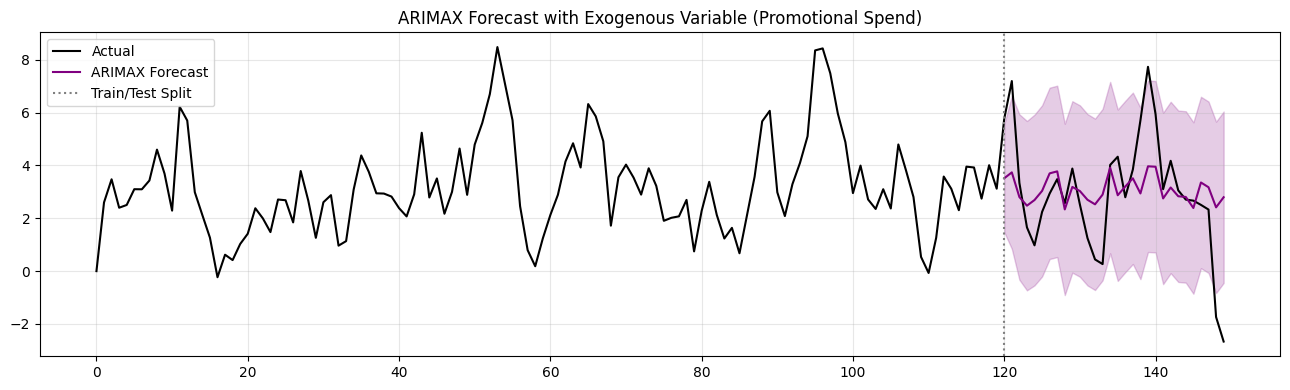

ARIMAX Estimated exogenous coefficient (promo):
  beta_promo = 1.6894 (true = 2.5)


In [13]:
# ARIMAX demonstration: synthetic data with an exogenous variable
np.random.seed(42)
n = 150

# Exogenous: promotional spend (normalised)
promo = np.random.uniform(0, 1, n)

# Generate series: ARMA(1,1) with exogenous effect
eps = np.random.normal(0, 1, n)
y_x = np.zeros(n)
for t in range(1, n):
    y_x[t] = 0.6 * y_x[t-1] + eps[t] + 0.4*eps[t-1] + 2.5 * promo[t]

series = pd.Series(y_x)
exog   = pd.DataFrame({'promo': promo})

train_x, test_x   = series.iloc[:120], series.iloc[120:]
exog_train, exog_test = exog.iloc[:120], exog.iloc[120:]

# Fit ARIMAX
arimax = ARIMA(train_x, order=(1, 0, 1), exog=exog_train).fit()
arimax_fc = arimax.get_forecast(steps=30, exog=exog_test)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(series.values, label='Actual', color='black')
fc_vals = arimax_fc.predicted_mean
fc_ci   = arimax_fc.conf_int()
ax.plot(range(120, 150), fc_vals, color='purple', label='ARIMAX Forecast')
ax.fill_between(range(120, 150), fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2, color='purple')
ax.axvline(120, color='gray', linestyle=':', label='Train/Test Split')
ax.set_title('ARIMAX Forecast with Exogenous Variable (Promotional Spend)')
ax.legend()
plt.tight_layout()
plt.show()

print("ARIMAX Estimated exogenous coefficient (promo):")
print(f"  beta_promo = {arimax.params['promo']:.4f} (true = 2.5)")

### 9. Case Study, Tools, and Summary

#### Case Study: Airline Passenger Forecasting (Full Pipeline)

The airline passenger dataset is a canonical benchmark. The complete modelling pipeline we followed:

| Step | Action | Result |
|------|--------|--------|
| 1. Explore | Plot raw series | Trend + seasonality detected |
| 2. Transform | Log transform | Stabilised variance |
| 3. Stationarity | ADF test | Original non-stationary, difference needed |
| 4. Differencing | d=1, D=1, s=12 | Stationary series achieved |
| 5. Order selection | ACF/PACF + AIC grid search | Best ARIMA(1,1,1); SARIMA(1,1,1)(1,1,1,12) |
| 6. Fit | MLE via Kalman filter | Parameters estimated |
| 7. Diagnose | Residual ACF, Ljung-Box, Q-Q plot | White noise residuals confirmed |
| 8. Forecast | 24-step ahead with 95% CI | SARIMA MAPE significantly lower |

#### Tools and Libraries

| Tool | Purpose |
|------|---------|
| `statsmodels.tsa.arima.ARIMA` | Fit ARIMA models |
| `statsmodels.tsa.statespace.SARIMAX` | SARIMA and ARIMAX |
| `statsmodels.tsa.stattools.adfuller` | ADF stationarity test |
| `statsmodels.graphics.tsaplots` | ACF/PACF plots |
| `pmdarima.auto_arima` | Automated order selection (stepwise AIC) |
| `sklearn.metrics` | RMSE, MAE evaluation |
| `pandas` | Time series indexing and manipulation |

In [14]:
# Auto ARIMA using pmdarima (demonstrates automated pipeline)
try:
    import pmdarima as pm
    auto_model = pm.auto_arima(
        np.log(passengers.iloc[:120]),
        seasonal=True, m=12,
        stepwise=True,
        information_criterion='aic',
        suppress_warnings=True,
        trace=True
    )
    print("\nBest model found:")
    print(auto_model.summary())
except ImportError:
    print("pmdarima not installed. Run: pip install pmdarima")
    print("auto_arima performs stepwise AIC minimisation to find optimal (p,d,q)(P,D,Q,s).")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-384.429, Time=2.00 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-277.702, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-381.231, Time=0.93 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-341.622, Time=0.50 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-118.985, Time=0.03 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=-389.711, Time=1.49 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=-365.957, Time=0.64 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=-387.782, Time=2.96 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=-383.806, Time=1.70 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=-385.824, Time=3.73 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-390.807, Time=1.16 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=-366.343, Time=0.54 sec
 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=-386.663, Time=1.78 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=-389.094, Time=2.93 sec
 ARIMA(1,0,2)(1,1,0

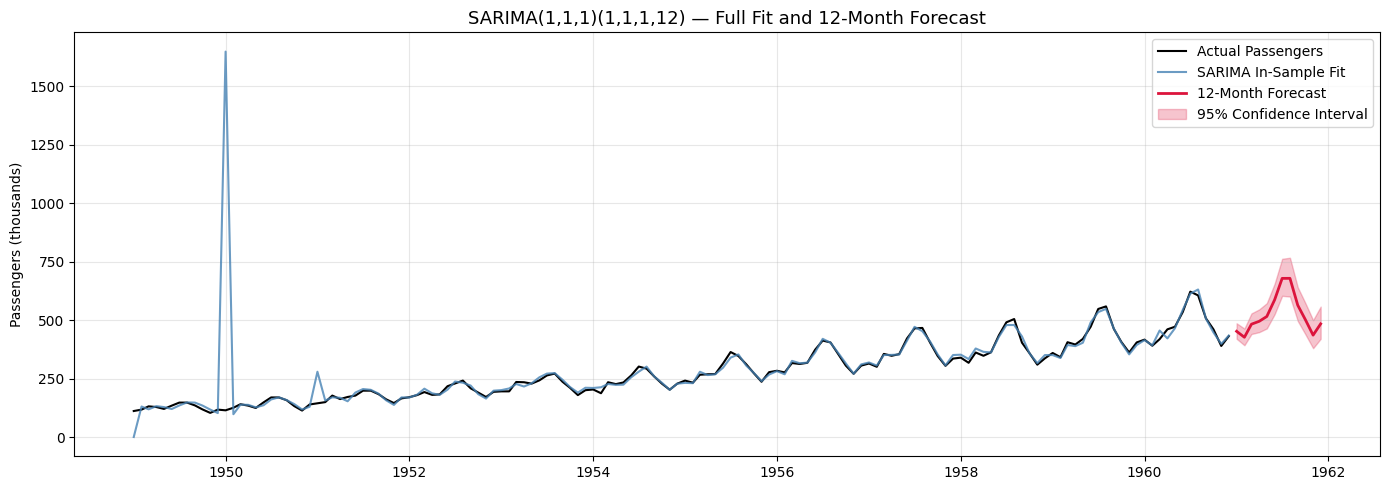

In [15]:
# Final summary visualization: Complete SARIMA forecast with training fit
sarima_full = SARIMAX(np.log(passengers),
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

# In-sample fit + future forecast (12 months)
in_sample  = np.exp(sarima_full.fittedvalues)
future_fc  = sarima_full.get_forecast(12)
future_mean = np.exp(future_fc.predicted_mean)
future_ci   = future_fc.conf_int().apply(np.exp)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(passengers, label='Actual Passengers', color='black', linewidth=1.5)
ax.plot(in_sample, label='SARIMA In-Sample Fit', color='steelblue', alpha=0.8)
ax.plot(future_mean, label='12-Month Forecast', color='crimson', linewidth=2)
ax.fill_between(future_mean.index,
                future_ci.iloc[:,0], future_ci.iloc[:,1],
                alpha=0.25, color='crimson', label='95% Confidence Interval')
ax.set_title('SARIMA(1,1,1)(1,1,1,12) — Full Fit and 12-Month Forecast', fontsize=13)
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

### Summary

#### ARIMA Modelling Workflow

```
Raw Data
   |-- Plot & explore
   |-- Test stationarity (ADF)
   |-- Transform & difference (d, D)
   |-- Inspect ACF/PACF --> candidate (p, q)
   |-- AIC/BIC grid search --> optimal (p, q)
   |-- Fit model (MLE)
   |-- Diagnose residuals (Ljung-Box, Q-Q plot)
   |-- Forecast + confidence intervals
```

#### Limitations of ARIMA

- Assumes **linear** relationships - cannot capture nonlinear dynamics
- Requires **stationarity** - transformation may distort interpretation  
- Poor with **structural breaks** - the model parameters are assumed constant
- Computationally expensive for very large $p, q$ orders
- For complex, high-dimensional data: consider **LSTM, Prophet, or Transformer-based** models

---
